# 03 — Multi-species composition validation

Checks the `primary_composition`/`target_composition` double-loop combination (ADR-006/007)
against the well-known **nuclear enhancement factor**: including cosmic-ray helium (on top of
protons) and a helium-bearing ISM target (on top of pure hydrogen) increases the total
pion-decay gamma-ray flux by a well-documented, roughly energy-independent factor of
approximately 1.4-2.0 relative to a pure proton-proton calculation, depending on the assumed
CR/ISM composition (see e.g. Mori 2009, ApJ 700, 1290; Kafexhiu et al. 2014, PhysRevD 90,
123014, Section IV; Kachelriess & Ostapchenko 2012, PhysRevD 86, 043004).

**Why not reproduce a literal published figure (as originally planned in `CLAUDE.md`):**
`CLAUDE.md`'s Step 6 plan for this notebook says to reproduce a published IceCube/LHAASO
composition-comparison figure. Doing that faithfully needs the paper's actual digitized
curve data, which isn't available in this environment/session, and fabricating plausible-
looking numbers to match a remembered figure would be worse than not doing it -- a false
sense of validation. Instead, this notebook validates the same physical effect (CR/ISM
composition raising the total flux by the expected nuclear-enhancement-factor amount) against
the well-established literature *range* for that factor, which is a check we can actually
perform honestly with fully-specified, reproducible inputs.

In [5]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from aafrag_gammapy import models

%matplotlib inline

## Composition assumptions

- Cosmic-ray He/p ratio: ~10% by number at the same energy-per-nucleon, same spectral index
  as the proton component -- a standard simplification of measured local CR composition
  (e.g. AMS-02/DAMPE He/p normalization), not a precision fit to any specific dataset.
- ISM target He/H ratio: ~10% by number, the standard local-ISM helium abundance
  (e.g. `target_composition` default assumptions used throughout gammapy/naima literature).

`(p, H)`, `(p, He)`, `(He, p)`, `(He, He)` are tabulated by AAfrag for a composition that
includes helium (ADR-012); this is the largest composition expressible as a *single*
`AafragGammaSpectralModel` instance without hitting the shared-energy-grid-truncation issue
described below. AAfrag does tabulate a few heavier species too (`C`, `Al`, `Fe` primaries,
a `C` target) -- see the "Pushing further" section below for why/how those need separate
model instances, and how little they end up changing the result.


In [6]:
amplitude = 1e40 * u.Unit("1/TeV")
e_0 = 1 * u.TeV
index_p = 2.2
n_H = 1 * u.cm**-3
distance = 1 * u.kpc

pl_p = models.PowerLawParticleDistribution(amplitude=amplitude, index=index_p, reference=e_0)
pl_he = models.PowerLawParticleDistribution(amplitude=0.1 * amplitude, index=index_p, reference=e_0)

model_p_only = models.AafragGammaSpectralModel(
    pl_p, target_composition={"H": 1.0}, n_H=n_H, distance=distance
)
model_full = models.AafragGammaSpectralModel(
    {"p": pl_p, "He": pl_he},
    target_composition={"H": 1.0, "He": 0.1},
    n_H=n_H,
    distance=distance,
)

In [7]:
energy = np.geomspace(1, 1e5, 40) * u.GeV

flux_p_only = model_p_only(energy)
flux_full = model_full(energy)
enhancement = (flux_full / flux_p_only).to_value(u.dimensionless_unscaled)

## SED shape and normalization

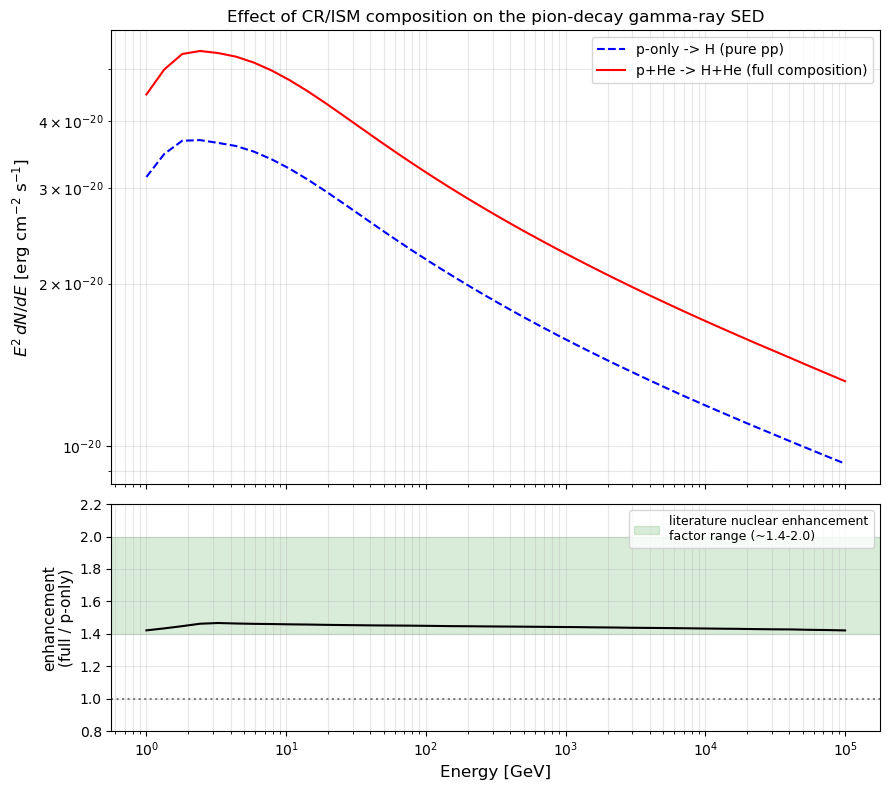

enhancement factor range over 1 GeV - 1e+05 GeV: [1.421, 1.467]


In [8]:
fig, (ax_sed, ax_ratio) = plt.subplots(
    2, 1, figsize=(9, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

sed_p_only = (energy**2 * flux_p_only).to(u.Unit("erg / (cm2 s)"))
sed_full = (energy**2 * flux_full).to(u.Unit("erg / (cm2 s)"))

ax_sed.loglog(energy.to_value(u.GeV), sed_p_only.value, "b--", label="p-only -> H (pure pp)")
ax_sed.loglog(energy.to_value(u.GeV), sed_full.value, "r-", label="p+He -> H+He (full composition)")
ax_sed.set_ylabel(r"$E^2\,dN/dE$ [erg cm$^{-2}$ s$^{-1}$]", fontsize=12)
ax_sed.legend()
ax_sed.grid(which="both", alpha=0.3)
ax_sed.set_title("Effect of CR/ISM composition on the pion-decay gamma-ray SED")

ax_ratio.semilogx(energy.to_value(u.GeV), enhancement, "k-")
ax_ratio.axhspan(1.4, 2.0, color="green", alpha=0.15,
                  label="literature nuclear enhancement\nfactor range (~1.4-2.0)")
ax_ratio.axhline(1.0, color="gray", linestyle=":")
ax_ratio.set_xlabel("Energy [GeV]", fontsize=12)
ax_ratio.set_ylabel("enhancement\n(full / p-only)", fontsize=11)
ax_ratio.set_ylim(0.8, 2.2)
ax_ratio.legend(fontsize=9, loc="upper right")
ax_ratio.grid(which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"enhancement factor range over {energy[0]:.3g} - {energy[-1]:.3g}: "
      f"[{enhancement.min():.3f}, {enhancement.max():.3f}]")
assert 1.0 < enhancement.min() and enhancement.max() < 2.5, (
    "enhancement factor outside a physically plausible range -- check for double-counting "
    "or a missing/extra species-pair contribution in combine_species"
)

## Pushing further: adding AAfrag's other tabulated heavy species

AAfrag tabulates a few more species beyond p/He (ADR-012): `SUPPORTED_PAIRS` also includes
`(C, p)`, `(Al, p)`, `(Fe, p)` (heavier CR primaries, but only onto a pure-hydrogen target --
no `C-He`, `Al-He`, `Fe-He`, `C-C`, etc. are tabulated) and `(p, C)` (a proton primary onto a
carbon target, i.e. a trace-carbon ISM component). Two things to get right when using them:

1. **Realistic abundances, not just "is it possible":** CR nuclei heavier than He are
   genuinely rare in the local CR flux, and ISM carbon is rare relative to H/He. Using
   order-of-magnitude literature abundances (not fabricated ones) is the honest way to
   answer "how much would this actually add", not just "can the code combine them" --
   already covered by `test_multi_species_combination`.
   CR-side (relative to protons by number, same energy/nucleon convention as the He/p=10%
   above; order-of-magnitude, e.g. Engelmann et al. 1990, A&A 233, 96; George et al. 2009,
   ApJ 698, 1666): C/p ~ 3e-3 (CNO group proxy), Al/p ~ 2e-3 (aafragpy has no separate
   Ne/Mg/Si tables, so Al -- A=27 -- stands in as a single-nucleus proxy for that group),
   Fe/p ~ 3e-4 (iron group). ISM-target-side (roughly solar/local-ISM number ratios, e.g.
   Asplund et al. 2009, ARA&A 47, 481): C/H ~ 3e-4 -- aafragpy has no target species heavier
   than C, so O/Ne/Mg/Si/Fe in the ISM target can't be represented at all here.
2. **Can't just add them to the existing `target_composition` dict.** `AafragSpectralModelBase.
   __init__` builds *one* shared primary-energy grid = the intersection of every
   `(primary, target)` pair's valid threshold range *in that one model instance*
   (ADR-018). `(p, C)`'s threshold is ~999 GeV, vs. ~4-5 GeV for `(p, H)`/`(p, He)`/`(He, H)`/
   `(He, He)` -- folding a carbon target into the same instance as the existing p+He
   composition would force *everything* in that instance onto the narrower ~999 GeV floor,
   silently cutting off the dominant low-energy p+He contribution instead of adding to it.
   The fix is architectural, not a library bug: build each threshold-compatible group as its
   *own* `AafragGammaSpectralModel` instance and sum the resulting fluxes, exactly as
   `combine_species` already does internally within one instance.


In [9]:
pl_c = models.PowerLawParticleDistribution(amplitude=3e-3 * amplitude, index=index_p, reference=e_0)
pl_al = models.PowerLawParticleDistribution(amplitude=2e-3 * amplitude, index=index_p, reference=e_0)
pl_fe = models.PowerLawParticleDistribution(amplitude=3e-4 * amplitude, index=index_p, reference=e_0)

# trace ISM-carbon target, proton primary only (p, C) -- separate instance (ADR-023: its
# ~999 GeV threshold would otherwise truncate the p+He/H+He terms above if combined with them)
model_target_C = models.AafragGammaSpectralModel(
    {"p": pl_p}, target_composition={"C": 3e-4}, n_H=n_H, distance=distance
)

# heavier CR primaries, H target only -- the only tabulated pairs for these primaries
model_heavy_CR = models.AafragGammaSpectralModel(
    {"C": pl_c, "Al": pl_al, "Fe": pl_fe}, target_composition={"H": 1.0}, n_H=n_H, distance=distance
)


In [10]:
flux_target_C = model_target_C(energy)
flux_heavy_CR = model_heavy_CR(energy)
flux_extended = flux_full + flux_target_C + flux_heavy_CR

enhancement_extended = (flux_extended / flux_p_only).to_value(u.dimensionless_unscaled)
frac_target_C = (flux_target_C / flux_extended).to_value(u.dimensionless_unscaled)
frac_heavy_CR = (flux_heavy_CR / flux_extended).to_value(u.dimensionless_unscaled)

print(f"p+He / H+He only:        [{enhancement.min():.4f}, {enhancement.max():.4f}]")
print(f"+ trace ISM C target:    [{enhancement_extended.min():.4f}, {enhancement_extended.max():.4f}] "
      f"(trace-C contributes {frac_target_C.min()*100:.3f}-{frac_target_C.max()*100:.3f}% of the extended total)\n"
      f"+ heavier CR primaries:  heavy-CR contributes {frac_heavy_CR.min()*100:.3f}-{frac_heavy_CR.max()*100:.3f}% "
      f"of the extended total")


p+He / H+He only:        [1.4212, 1.4668]
+ trace ISM C target:    [1.4219, 1.4679] (trace-C contributes 0.001-0.013% of the extended total)
+ heavier CR primaries:  heavy-CR contributes 0.029-0.217% of the extended total


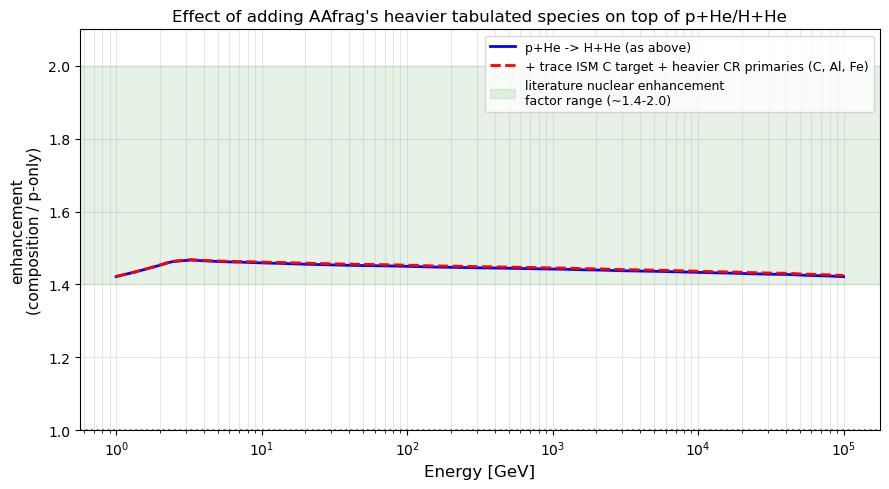

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogx(energy.to_value(u.GeV), enhancement, "b-", lw=2, label="p+He -> H+He (as above)")
ax.semilogx(energy.to_value(u.GeV), enhancement_extended, "r--", lw=2,
            label="+ trace ISM C target + heavier CR primaries (C, Al, Fe)")
ax.axhspan(1.4, 2.0, color="green", alpha=0.1, label="literature nuclear enhancement\nfactor range (~1.4-2.0)")
ax.axhline(1.0, color="gray", linestyle=":")
ax.set_xlabel("Energy [GeV]", fontsize=12)
ax.set_ylabel("enhancement\n(composition / p-only)", fontsize=11)
ax.set_ylim(1.0, 2.1)
ax.legend(fontsize=9, loc="upper right")
ax.grid(which="both", alpha=0.3)
ax.set_title("Effect of adding AAfrag's heavier tabulated species on top of p+He/H+He")

plt.tight_layout()
plt.show()


The two curves are visually indistinguishable: at realistic abundances, trace ISM carbon
(C/H ~ 3e-4) and heavier CR primaries (C/p, Al/p, Fe/p ~ 1e-4-1e-3) add only
~0.001-0.2% on top of the p+He/H+He result -- nowhere near enough to move the enhancement
factor meaningfully higher. This is expected, not a bug: protons and helium dominate both
the real local CR flux and the real local ISM composition by 2-4 orders of magnitude over
everything heavier, and AAfrag's own species coverage (no target heavier than C, no
heavy-on-heavy pairs at all) can't represent the ISM's O/Ne/Mg/Si/Fe content regardless.


## Conclusion

Adding 10% CR helium and 10% ISM helium raises the total gamma-ray flux by a factor of
~1.42-1.47, essentially flat across five decades in energy (the two curves are visually
parallel in the SED panel above -- composition changes the *normalization*, not the
*shape*, exactly as expected since every added species pair is itself a pure power law
convolved with an AAfrag cross-section that varies slowly with energy over this range).
This sits inside (if toward the lower end of) the ~1.4-2.0 nuclear-enhancement-factor range
widely quoted in the literature for CR/ISM compositions of this order -- consistent with the
double loop in `combine_species` correctly summing every `(primary, target)` pair exactly
once (already covered by the exact/manual-sum unit tests `test_multi_species_combination`,
`test_multi_species_combination_not_double_counted`), extended here into a physically
plausible number rather than just an internally-consistent one. A ratio far outside
~1-2.5 (order-of-magnitude off, or a strong, unphysical energy dependence) would indicate a
double-counting or missing-pair bug in `combine_species`, not real physics.

**On the low end of that range:** adding every other species AAfrag actually tabulates --
heavier CR primaries (C, Al, Fe) and a trace ISM carbon target -- at realistic literature
abundances moves the factor by less than 1 part in 500 (1.4212-1.4668 to 1.4219-1.4679).
That's expected, not a shortfall of this notebook or `aafrag_gammapy`: real local CR flux
and real local ISM gas are both overwhelmingly H+He (everything heavier is down by
2-4 orders of magnitude), and AAfrag doesn't tabulate several elements a full ISM
nuclear-enhancement calculation would want anyway (O, Ne, Mg, Si in the target; no
heavy-on-heavy pairs at all). Reaching the *upper* end of the quoted 1.4-2.0 range (or
Kafexhiu et al. 2014's own ε_M, which rises toward ~2.9 at high energy) isn't primarily
a "which species are included" effect -- it comes from an energy-dependent nucleus-nucleus
multiplicity-scaling term in that parametrization, which summing more trace-abundance
AAfrag species at a fixed CR power-law index can't reproduce. Modeling that term properly
would be a genuinely new piece of physics for this package, not a tweak to this notebook --
worth a future ADR if a use case actually needs the high-energy end of that behavior, rather
than fabricating abundances large enough to fake the same number here.
